In [1]:
print("Rohit")

Rohit


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/final_dataset.csv", parse_dates=["timestamp"])
target = "load_actual"

# Train–test split by timestamp
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

y_train = train[target]
y_test = test[target]


In [3]:
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler

# Use all features except timestamp and target
X = df.drop(columns=["timestamp", target])
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

# Scale inputs
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Best general SVR configuration
svm = SVR(kernel='rbf', C=100, gamma='scale')
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

# Metrics
mae_svm = mean_absolute_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))
mape_svm = np.mean(np.abs((y_test - y_pred_svm) / y_test)) * 100

print("SVM MAE :", mae_svm)
print("SVM RMSE:", rmse_svm)
print("SVM MAPE:", mape_svm)


SVM MAE : 3129.2803130275734
SVM RMSE: 3963.1067673767757
SVM MAPE: 11.00806111518004


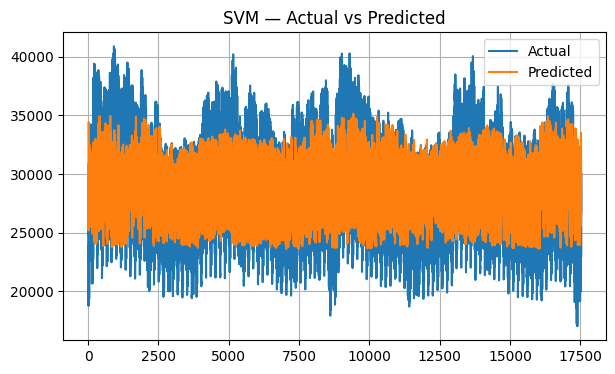

In [4]:
plt.figure(figsize=(7,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_svm, label="Predicted")
plt.title("SVM — Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler

X = df.drop(columns=["timestamp", target])
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    random_state=42
)

gbr.fit(X_train_scaled, y_train)
y_pred_gb = gbr.predict(X_test_scaled)

# Metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mape_gb = np.mean(np.abs((y_test - y_pred_gb) / y_test)) * 100

print("GB MAE :", mae_gb)
print("GB RMSE:", rmse_gb)
print("GB MAPE:", mape_gb)

GB MAE : 3000.139822243602
GB RMSE: 3749.785279240799
GB MAPE: 10.639066850976302


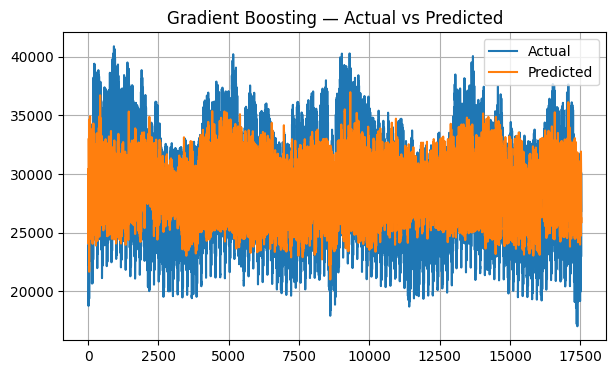

In [6]:
plt.figure(figsize=(7,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_gb, label="Predicted")
plt.title("Gradient Boosting — Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from pmdarima import auto_arima

# Use only the target series for ARIMA
model_arima = auto_arima(
    y_train,
    seasonal=False,
    trace=False,
    error_action='ignore',
    suppress_warnings=True
)

y_pred_arima = model_arima.predict(n_periods=len(y_test))

# Metrics
mae_arima = mean_absolute_error(y_test, y_pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_test, y_pred_arima))
mape_arima = np.mean(np.abs((y_test - y_pred_arima) / y_test)) * 100

print("ARIMA MAE :", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAPE:", mape_arima)


In [ ]:
ts = df["load_actual"]

In [ ]:
train_size = int(len(ts) * 0.8)

train_ar = ts.iloc[:train_size]
test_ar  = ts.iloc[train_size:]

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import itertools
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

p = [0, 1, 2]
d = [0, 1]
q = [0, 1, 2]

best_aic = np.inf
best_order = None
best_model = None

for comb in itertools.product(p, d, q):
    try:
        model = ARIMA(train_ar, order=comb).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = comb
            best_model = model
    except:
        continue

print("Best ARIMA Order:", best_order)
print("Best AIC:", best_aic)


In [ ]:
n = len(test_ar)
y_pred_arima = best_model.forecast(steps=n)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(test_ar, y_pred_arima)
mse  = mean_squared_error(test_ar, y_pred_arima)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test_ar - y_pred_arima) / test_ar)) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

In [ ]:
# Plot
plt.figure(figsize=(8,4))
plt.plot(test_ar.values, label="Actual", linewidth=2)
plt.plot(y_pred_arima, label="Predicted", linewidth=2)
plt.title("ARIMA (Auto-Tuned) - Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()